# assignment 3

## AI usage

In this assignment I used ChatGPT 5.5 as support for the following tasks:

- Assisted in understanding the Ollama/API connection and how to test the Gemma 3 models.
- Helped explain Python error messages when the code did not run as expected.
- Assisted with understanding preprocessing steps for the Bank Marketing dataset, such as encoding and scaling.
- Text and spell checking.

## Task 0

In [1]:
# a)
import requests

# Ollama local API endpoint
url = "http://localhost:11434/api/generate"

payload = {
    "model": "gemma3:270m",
    "prompt": "write me a for loop in python for finding the max value in a list. Keep it brief :D",
    "stream": False
}

response = requests.post(url, json=payload)

if response.status_code == 200:
    result = response.json()
    print(result["response"])
else:
    print("Error:", response.status_code)
    print(response.text)

```python
for item in list_of_items:
    if item > 0:
        print(item)
```



In [2]:
# b)

# I loaded the 270m parameter version of the Gemma 3 model and tested it with a simple prompt using Ollama's local API.

import requests

# Task 0b: Load and test Gemma 3 270m through Ollama's local API
url = "http://localhost:11434/api/generate"

payload = {
    "model": "gemma3:270m",
    "prompt": "Write me a 100 word story about python",
    "stream": False
}

response = requests.post(url, json=payload)

if response.status_code == 200:
    result = response.json()
    print("Gemma 3 270m response:")
    print(result["response"])
else:
    print("Error:", response.status_code)
    print(response.text)

Gemma 3 270m response:
Python's elegant syntax and dynamic typing make it a versatile language. It's perfect for data science, web development, and scripting. From simple tasks to complex projects, Python's ease of use allows anyone to build and maintain their applications. Its focus on readability and efficiency makes it a joy to learn and use.



In [3]:
### Task 0c

# I loaded the 4b parameter version of the Gemma 3 model and tested it with a simple prompt using Ollama's local API.

import requests

# Task 0c: Load and test Gemma 3 4b through Ollama's local API
url = "http://localhost:11434/api/generate"

payload = {
    "model": "gemma3:4b",
    "prompt": "Explain what a large language model is in one short sentence.",
    "stream": False
}

response = requests.post(url, json=payload)

if response.status_code == 200:
    result = response.json()
    print("Gemma 3 4b response:")
    print(result["response"])
else:
    print("Error:", response.status_code)
    print(response.text)

Gemma 3 4b response:
A large language model is a sophisticated AI that learns to predict and generate human-like text by analyzing massive amounts of data.


## Task 1

In [4]:
# a)

# I define a function that classifies an email headline as spam, work, or unknown. The function uses a local Ollama model and returns only the classification.

import requests

def classify_email_headline(headline, model="gemma3:270m"):
    """
    Classifies an email headline as spam, work, or unknown using Ollama.
    Returns only one of: spam, work, unknown.
    """
    
    url = "http://localhost:11434/api/generate"
    
    prompt = f"""
You are an email headline classifier.

Classify this email headline as exactly one of:
spam
work
unknown

Definitions:
spam = scams, suspicious offers, prizes, dating ads, fake urgent account messages
work = meetings, reports, reviews, projects, documents, colleagues, workplace tasks
unknown = vague headlines where the title alone is not enough

Return only one word. Do not explain.

Headline: "{headline}"

Classification:
"""

    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0
        }
    }
    
    response = requests.post(url, json=payload)
    
    if response.status_code != 200:
        return "error"
    
    result = response.json()["response"].strip().lower()
    # Keep only the first word/line from the model response
    result = result.split()[0].replace(".", "").replace(",", "").replace(":", "")
    
    if result in ["spam", "work", "unknown"]:
        return result
    else:
        return "unknown"

In [5]:
# Task 1b

# I use the smaller Gemma 3 270m model to classify all email headlines in the dataset.

import pandas as pd

# Read the email headlines manually because the file contains unquoted commas
with open("data/emails.csv", "r", encoding="utf-8") as file:
    headlines = [line.strip() for line in file if line.strip()]

# Remove the header row
headlines = headlines[1:]

# Create DataFrame
emails_df = pd.DataFrame(headlines, columns=["headline"])

display(emails_df)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


In [6]:
email_classifications_270m = []

for headline in emails_df["headline"]:
    classification = classify_email_headline(headline, model="gemma3:270m")
    email_classifications_270m.append(classification)

emails_df["gemma3_270m"] = email_classifications_270m

display(emails_df)

,headline,gemma3_270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,unknown
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,unknown


In [7]:
# The model seems to mostly identify the mails as spam, probably due to the smaller gemma3:270m model... :(

In [8]:
# Task 1c

# I use the larger Gemma 3 4b model to classify the same email headlines and compare the results with the smaller 270m model.

# Classify all email headlines using Gemma 3 4b
email_classifications_4b = []

for headline in emails_df["headline"]:
    classification = classify_email_headline(headline, model="gemma3:4b")
    email_classifications_4b.append(classification)

# Add the 4b classifications to the same DataFrame
emails_df["gemma3_4b"] = email_classifications_4b

display(emails_df)

,headline,gemma3_270m,gemma3_4b
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam
4,Meeting agenda for Thursday's project review,unknown,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work
8,Quick question about last week,spam,unknown
9,Following up,unknown,work


In [9]:
# The 4b model performed better than the 270m model. The 270m model classified almost everything as spam, including several clear work emails. The 4b model correctly identified most spam and work emails, but still struggled with some vague headlines. Overall, the 4b model was more reliable because it followed the instructions better.

In [10]:
# Task 1d

# I repeat the classification three times for both models and store the results in a new DataFrame.

In [11]:
# Create a new DataFrame with the original headlines
comparison_df = emails_df[["headline"]].copy()

# Repeat classification 3 times for both models
for run in range(1, 4):
    results_270m = []
    results_4b = []
    
    for headline in comparison_df["headline"]:
        results_270m.append(classify_email_headline(headline, model="gemma3:270m"))
        results_4b.append(classify_email_headline(headline, model="gemma3:4b"))
    
    comparison_df[f"gemma3_270m_run_{run}"] = results_270m
    comparison_df[f"gemma3_4b_run_{run}"] = results_4b

display(comparison_df)

,headline,gemma3_270m_run_1,gemma3_4b_run_1,gemma3_270m_run_2,gemma3_4b_run_2,gemma3_270m_run_3,gemma3_4b_run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,unknown,work,unknown,work,unknown,work
5,"Q3 budget report attached, please review by Fr...",spam,work,spam,work,spam,work
6,Reminder: Annual performance review scheduled ...,spam,work,spam,work,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work,spam,work,spam,work
8,Quick question about last week,spam,unknown,spam,unknown,spam,unknown
9,Following up,unknown,work,unknown,work,unknown,work


In [12]:
# The results varied slightly, mainly for vague headlines. This is expected because LLM outputs can vary between runs. The 270m model was less stable, while the 4b model was more consistent.

# Task 2

In [13]:
# a)
# Read news.csv manually because some headlines contain unquoted commas
with open("data/news.csv", "r", encoding="utf-8") as file:
    news_headlines = [line.strip() for line in file if line.strip()]

# Remove header row
news_headlines = news_headlines[1:]

# Create DataFrame
news_df = pd.DataFrame(news_headlines, columns=["headline"])

display(news_df)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


In [14]:
# These should already be imported from previous tasks, but just for safety
import requests
import json
import re

def classify_news_headline(headline, model="gemma3:4b"):
    """
    Classifies a financial news headline by topic and sentiment.
    Returns the result in JSON format.
    """

    url = "http://localhost:11434/api/generate"

    prompt = f"""
Classify the following financial news headline.

Choose exactly one topic:
earnings
mergers
regulation
macroeconomics

Choose exactly one sentiment:
positive
negative
neutral

Return only valid JSON in this format:
{{"topic": "earnings", "sentiment": "positive"}}

Headline: "{headline}"
"""

    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0
        }
    }

    response = requests.post(url, json=payload)

    if response.status_code != 200:
        return {"topic": "unknown", "sentiment": "unknown"}

    result = response.json()["response"].strip()

    # Extract JSON from the response
    match = re.search(r"\{.*\}", result, re.DOTALL)

    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            return {"topic": "unknown", "sentiment": "unknown"}

    return {"topic": "unknown", "sentiment": "unknown"}

In [15]:
classify_news_headline(news_df["headline"].iloc[0], model="gemma3:4b")

{'topic': 'earnings', 'sentiment': 'positive'}

In [16]:
# b)
# Classify all news headlines using Gemma 3 4b
news_results = []

for headline in news_df["headline"]:
    result = classify_news_headline(headline, model="gemma3:4b")
    
    news_results.append({
        "headline": headline,
        "topic": result["topic"],
        "sentiment": result["sentiment"]
    })

# Create a new DataFrame with headline, topic and sentiment
news_classification_df = pd.DataFrame(news_results)

display(news_classification_df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


In [17]:
for i, headline in enumerate(news_df["headline"], start=1):
    print(f"{i}. {headline}")

1. Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
2. Helvora Pharmaceuticals misses earnings forecast amid weak generics demand
3. Aurelis Bank reports steady quarterly profit, in line with analyst expectations
4. Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal
5. Antitrust regulators block proposed merger between Solenta and Marvex Energy
6. Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG
7. New EU AI Act compliance rules expected to raise costs for Lumavex by 12%
8. Finnish FSA grants Norvik Capital expanded licence for cross-border operations
9. Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs
10. Rising interest rates weigh on Tessaro Real Estate as financing costs climb


# c)

I gave the same headlines and classification options to ChatGPT as the browser-based LLM. The results were:

| Headline | Topic | Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | neutral |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | regulation | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

The browser-based LLM and Gemma 3 4b gave quite similar answers.

The main differences were in headlines that can be understood in more than one way. For example, ChatGPT saw the Finnish FSA licence and lower inflation as positive, while Gemma 3 4b saw them as neutral.

I think the browser-based LLM was a little better, because it understood the business meaning of the headlines more clearly.

# Task 3

In [18]:
# a)

# (This should allready be imported, but if you decide to run just this task, then here we go)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset
df = pd.read_csv("data/bank-additional.csv", sep=";")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Shape: (4119, 21)

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64

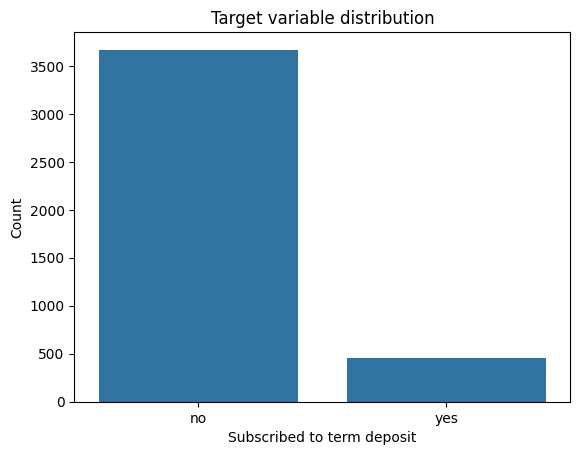

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [19]:
# Basic overview
display(df.head())
print("Shape:", df.shape)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Data types
print("\nData types:")
print(df.dtypes)

# Target variable
print("\nTarget variable counts:")
print(df["y"].value_counts())

print("\nTarget variable percentages:")
print(df["y"].value_counts(normalize=True) * 100)

# Simple plot of target variable
sns.countplot(data=df, x="y")
plt.title("Target variable distribution")
plt.xlabel("Subscribed to term deposit")
plt.ylabel("Count")
plt.show()

# Basic statistics
display(df.describe())

In [20]:
# b)
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Make a copy of the dataset
df_processed = df.copy()

# Encode target variable y numerically
df_processed["y"] = df_processed["y"].map({"yes": 1, "no": 0})

# Label encoding for categorical variables
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in df_processed.select_dtypes(include=["object"]).columns:
    df_processed[col] = label_encoder.fit_transform(df_processed[col])

# Standardization for numerical variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_processed.drop(columns=["y"])
y = df_processed["y"]

X[X.columns] = scaler.fit_transform(X[X.columns])

# Check result
display(X.head())
print("Target variable:")
print(y.value_counts())

C:\Users\karle\AppData\Local\Temp\ipykernel_36740\3773532090.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_processed.select_dtypes(include=["object"]).columns:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,-0.980752,-0.783431,-0.291925,-0.828300,-0.492099,0.933554,-0.469803,-0.743752,0.739737,-1.446809,0.903952,-0.209228,0.201031,-0.351356,0.203199,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779
1,-0.107991,0.880518,1.357513,-0.363038,-0.492099,-1.099388,-0.469803,1.344534,0.739737,-1.446809,0.350300,0.569634,0.201031,-0.351356,0.203199,0.649441,0.715193,0.892269,0.711698,0.332862
2,-1.465619,0.880518,-0.291925,-0.363038,-0.492099,0.933554,-0.469803,1.344534,-0.127977,1.432827,-0.116966,-0.598660,0.201031,-0.351356,0.203199,0.841389,1.528273,-0.283172,0.773427,0.836535
3,-0.204965,0.880518,-0.291925,-0.828300,-0.492099,-0.082917,0.878711,1.344534,-0.127977,-1.446809,-0.941553,0.180203,0.201031,-0.351356,0.203199,0.841389,1.528273,-0.283172,0.771697,0.836535
4,0.667795,-1.060755,-0.291925,1.032748,-0.492099,0.933554,-0.469803,-0.743752,1.173594,-0.726900,-0.780563,-0.598660,0.201031,-0.351356,0.203199,-0.118350,-0.655478,-0.326707,0.328632,0.398028


Target variable:
y
0    3668
1     451
Name: count, dtype: int64


### After this point i started focusing on the project instead :)